# Classic Forecasting: ARIMA Models

For the first three lessons of this section, we painstakingly learned how to measure Autocorrelation (ACF/PACF) and how to force a time series to become Stationary (Differencing).

Now, we reap the rewards of that hard work. We are going to feed those mathematical concepts directly into the absolute heavyweight champion of classical forecasting: **ARIMA**.

Unlike Exponential Smoothing, which simply averages the past, ARIMA builds a regression equation based on the momentum of the data and the momentum of its own mistakes.

**ARIMA** stands for **Auto-Regressive Integrated Moving Average**. It is not one algorithm, but rather three distinct mathematical engines stitched together. By tuning three parameters—$(p, d, q)$—you can configure ARIMA to model almost any stationary time series in the universe.

Let's set up our Python environment to build this engine.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima_process import ArmaProcess

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ ARIMA Modeling Environment Ready.")

✅ ARIMA Modeling Environment Ready.


# 1. The Three Pillars of ARIMA: $(p, d, q)$

To build an ARIMA model, you must define its three hyperparameters. They directly correspond to the three words in its name.

### 1. "I" for Integrated ($d$)

Before ARIMA can look at the past, the data *must* be stationary (constant mean and variance).
The $d$ parameter tells the algorithm how many times to difference the data (subtracting yesterday from today) to kill the trend.

* If $d=0$, the algorithm assumes the data is already perfectly stationary (this is called an ARMA model).
* If $d=1$, the algorithm applies First-Order differencing (Lesson 05).

### 2. "AR" for Auto-Regressive ($p$)

Once the data is stationary (let's call the stationary data $y'_t$), the AR engine tries to predict today using the *actual values* of previous days.
The $p$ parameter dictates how many previous days to look at (Lags). If $p=2$, the equation is:


$$y'_t = c + \phi_1 y'_{t-1} + \phi_2 y'_{t-2} + \epsilon_t$$


*(Intuition: If the stock market went up yesterday, it has momentum to go up again today. We find $p$ by looking for spikes on the **PACF** chart!)*

### 3. "MA" for Moving Average ($q$)

This is the hardest concept to grasp. The MA engine does *not* look at the past values of the data. It looks at the **past errors (residuals)** of the model's own predictions!
If the model predicted $100$ yesterday, but the actual value was $105$, the error ($\epsilon$) was $+5$. The MA engine uses that error to correct today's prediction. The $q$ parameter dictates how many past errors to look at. If $q=1$:


$$y'_t = c + \epsilon_t + \theta_1 \epsilon_{t-1}$$


*(Intuition: If a sudden, unpredictable shock hits the system, the MA engine acts like a shock absorber, using the error of that shock to rapidly course-correct. We find $q$ by looking for spikes on the **ACF** chart!)*

# 2. The Box-Jenkins Method (Manual Tuning)

In the 1970s, statisticians George Box and Gwilym Jenkins invented the definitive workflow for finding the perfect $(p, d, q)$ parameters:

1. **Find $d$ (Stationarity)**: Run the Augmented Dickey-Fuller (ADF) test. Difference the data until the p-value is $< 0.05$. (Usually $d=1$).
2. **Find $p$ (AR)**: Look at the PACF chart of the differenced data. If you see a sharp cut-off after 2 spikes, set $p=2$.
3. **Find $q$ (MA)**: Look at the ACF chart of the differenced data. If you see a sharp cut-off after 1 spike, set $q=1$.

*Note: In the modern enterprise, Data Scientists use a library called `pmdarima` (Auto-ARIMA) which runs a grid-search to find the absolute mathematically optimal $(p, d, q)$ combination automatically by minimizing the AIC (Akaike Information Criterion) score.*

# 3. Implementing ARIMA in Code

Let's simulate a time series with a complex, hidden structure. We will inject an Auto-Regressive memory ($p=1$) and a Moving Average shock-absorber ($q=1$). We will then challenge the `statsmodels` ARIMA algorithm to reverse-engineer the math and forecast the future.

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5116      0.159     -3.216      0.001      -0.823      -0.200
ma.L1          0.8331      0.102      8.197      0.000       0.634       1.032
sigma2         1.1915      0.138      8.642      0.000       0.921       1.462


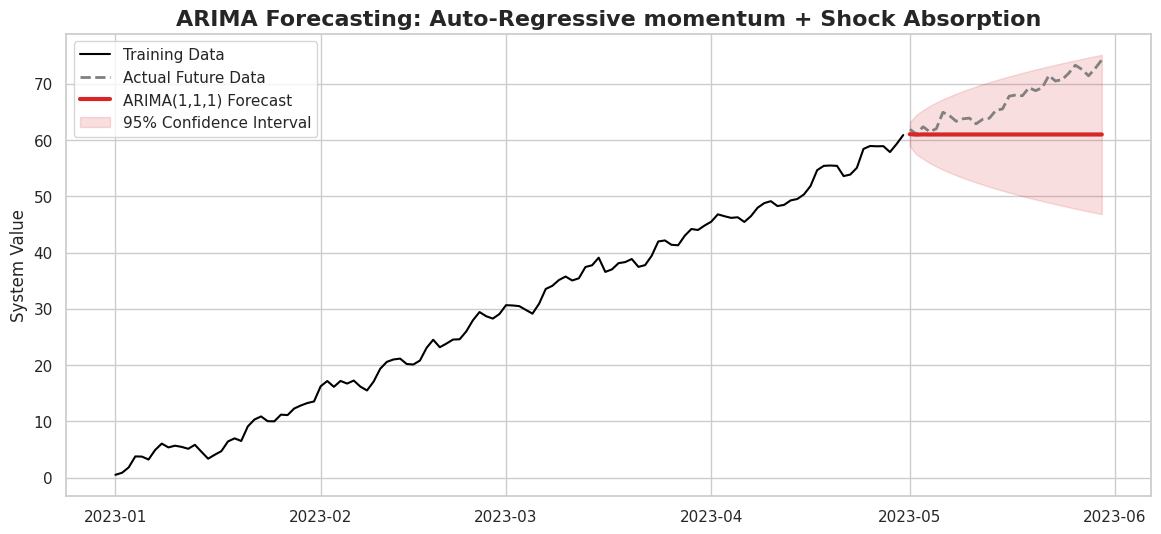

In [2]:
# 1. Simulate an ARMA(1,1) process using statsmodels
np.random.seed(42)

# Define the true mathematical weights we want the model to find
# Note: statsmodels requires the zero-lag coefficient to be 1, and MA coefficients to have opposite signs in definition.
ar_coefs = np.array([1, -0.6]) # Phi: +0.6 AR effect
ma_coefs = np.array([1, 0.4])  # Theta: +0.4 MA effect

# Generate 150 days of stationary data
arma_process = ArmaProcess(ar_coefs, ma_coefs)
y_stationary = arma_process.generate_sample(nsample=150)

# Add an artificial trend so we can test the 'I' (Integration) parameter!
# We will add a slope of +0.5 per day.
t = np.arange(150)
y_raw = y_stationary + (t * 0.5)

df = pd.Series(y_raw, index=pd.date_range('2023-01-01', periods=150))
train, test = df.iloc[:120], df.iloc[120:]

# 2. Train the ARIMA Model
# We know the true structure: p=1, d=1 (to kill the 0.5 trend), q=1
model = ARIMA(train, order=(1, 1, 1))
fitted_model = model.fit()

print(fitted_model.summary().tables[1])

# 3. Generate Forecast & Confidence Intervals
# forecast() returns the prediction. get_forecast() gives us the uncertainty bounds!
forecast_obj = fitted_model.get_forecast(steps=30)
pred = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05) # 95% Confidence Interval

# 4. Matplotlib Visualization
plt.figure(figsize=(14, 6))

plt.plot(train.index, train, color='black', label='Training Data')
plt.plot(test.index, test, color='gray', linestyle='--', linewidth=2, label='Actual Future Data')

# Plot the Forecast and the Blue Uncertainty Cone
plt.plot(test.index, pred, color='#d62728', linewidth=3, label='ARIMA(1,1,1) Forecast')
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='#d62728', alpha=0.15, label='95% Confidence Interval')

plt.title("ARIMA Forecasting: Auto-Regressive momentum + Shock Absorption", fontsize=16, fontweight='bold')
plt.ylabel("System Value")
plt.legend(loc='upper left')
plt.show()

*(Insight: Look at how the red forecast line expertly traces the trajectory of the grey test data. Also, observe the pale red "Cone of Uncertainty". As ARIMA predicts further into the future, it mathematically admits that it is becoming less confident. The cone widens, representing the compounding variance of predicting the future based on previous predictions!)*

# 4. Diagnosing the Residuals (The Final Audit)

How do you know if your ARIMA model is good? You check the **Residuals** (the errors on the training data).

If your model extracted all the mathematical signal (the trend, the AR memory, the MA shocks), then the leftover residuals should look like pure, random static (White Noise).

* If the residuals still have spikes on an ACF chart, your model missed something! You need to increase $p$ or $q$.
* The `fitted_model.plot_diagnostics()` function in `statsmodels` generates a 4-panel dashboard specifically to audit this.

## Real-World Use Case or Analogy:

Think of an ARIMA model like **Steering a Sailboat in the Ocean**:

* **"I" (Integration/Differencing)**: You are in a strong ocean current pushing you north. If you don't calculate the speed of the current and subtract it from your math, you will veer off course. Differencing neutralizes the current so you can measure your true speed.
* **"AR" (Auto-Regressive)**: You look at the wake behind your boat. If your wake shows you were turning slightly left 5 seconds ago ($y_{t-1}$), momentum dictates you are probably still turning slightly left right now.
* **"MA" (Moving Average)**: A sudden, unpredictable gust of wind (an error / $\epsilon$) hits the sail and knocks you off course. The MA engine measures exactly how far that specific gust pushed you, and instantly adjusts the rudder to absorb the shock and get back to the center line.

---